In [11]:
!pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install seaborn



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import sys
!{sys.executable} -m pip install seaborn

In [8]:
# fetch the dataset
data= pd.read_csv(r"C:\Users\dell\Downloads\retail_store_inventory.csv")

In [9]:
data

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73095,2024-01-01,S005,P0016,Furniture,East,96,8,127,18.46,73.73,20,Snowy,0,72.45,Winter
73096,2024-01-01,S005,P0017,Toys,North,313,51,101,48.43,82.57,10,Cloudy,0,83.78,Autumn
73097,2024-01-01,S005,P0018,Clothing,West,278,36,151,39.65,11.11,10,Rainy,0,10.91,Winter
73098,2024-01-01,S005,P0019,Toys,East,374,264,21,270.52,53.14,20,Rainy,0,55.80,Spring


In [10]:
data.shape

(73100, 15)

In [11]:
data.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [13]:
data.dtypes

Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Demand Forecast       float64
Price                 float64
Discount                int64
Weather Condition      object
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality            object
dtype: object

In [16]:
# extract the month,year from the date column in separate column
data["Years"]= data["Date"].dt.year
data["Months"]= data["Date"].dt.month_name()

In [17]:
data.Years.head()


0    2022
1    2022
2    2022
3    2022
4    2022
Name: Years, dtype: int32

In [18]:
data.Months.head()

0    January
1    January
2    January
3    January
4    January
Name: Months, dtype: object

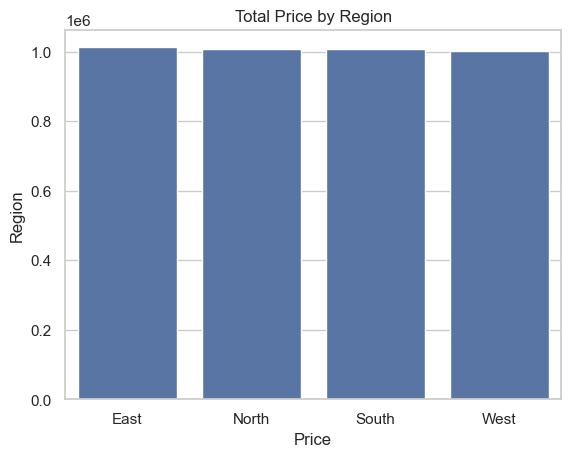

In [24]:
#charts 1.column chart
# style
sns.set(style="whitegrid")
# groupby (according to region)
region_price = data.groupby("Region")["Price"].sum().reset_index()
sns.barplot(x=region_price["Region"],y=region_price["Price"])
plt.title("Total Price by Region")
plt.xlabel("Price")
plt.ylabel("Region")
plt.show()

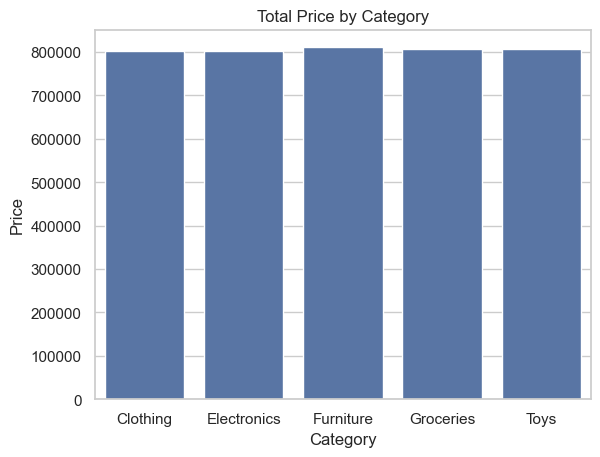

In [26]:
# according to category
cat_price=data.groupby("Category")["Price"].sum().reset_index()
sns.barplot(x=cat_price["Category"],y=cat_price["Price"])
plt.title("Total Price by Category")
plt.xlabel("Category")
plt.ylabel("Price")
plt.show()

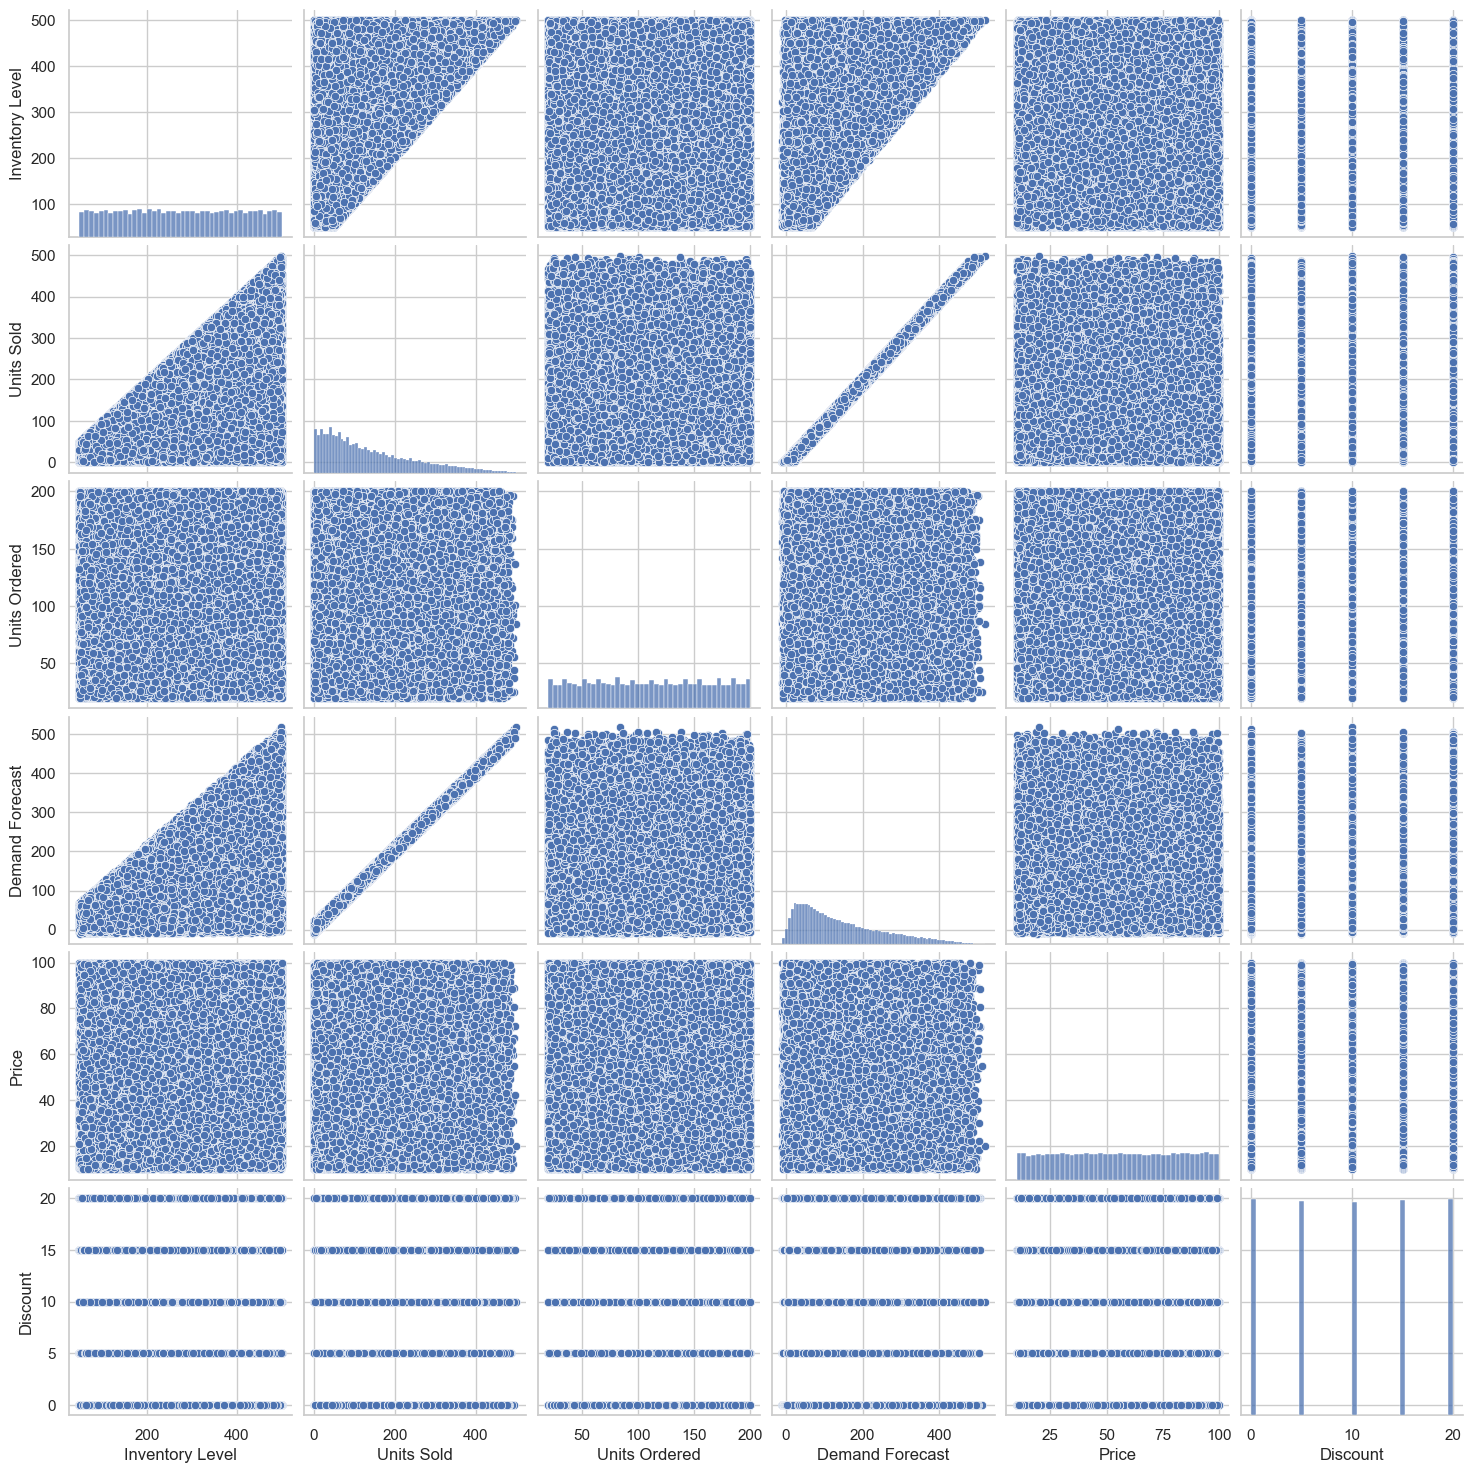

In [29]:
#pairplot
sns.pairplot(data[[
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Demand Forecast",
    "Price",
    "Discount"
]])
plt.show()


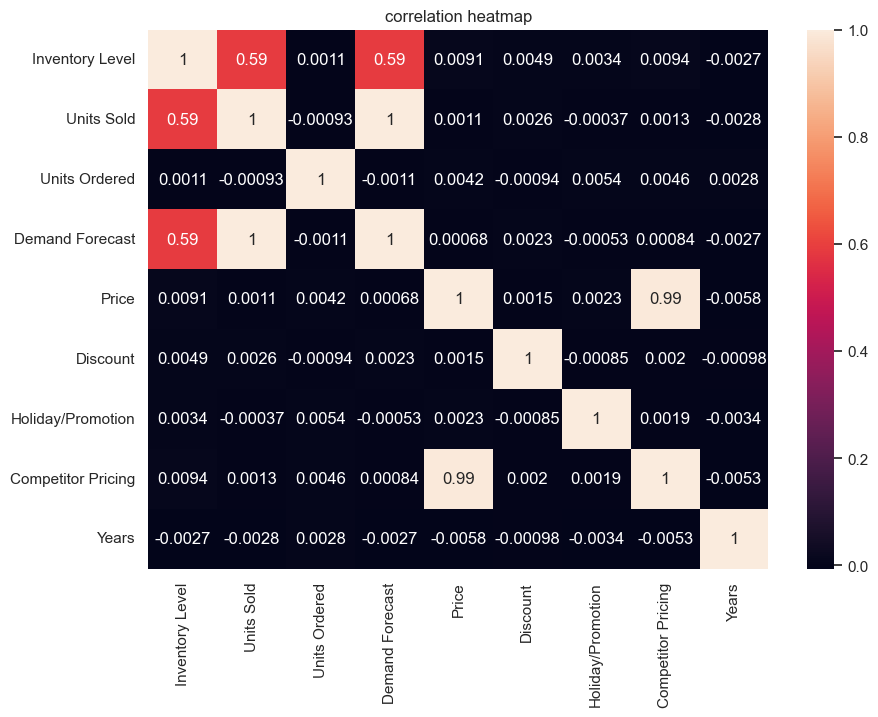

In [31]:
# corelation chart (heatmap)
plt.figure(figsize=(10,7))
sns.heatmap(data.corr(numeric_only=True),annot=True)
plt.title("correlation heatmap")
plt.show()



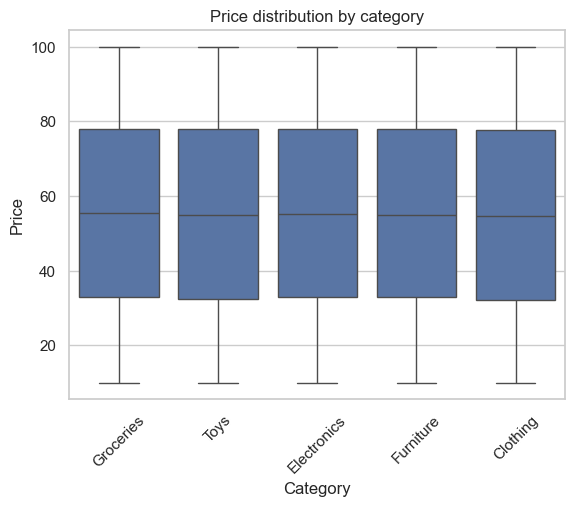

In [34]:
# boxplot(to dedect outliers)
sns.boxplot(x="Category",y="Price",data=data)
plt.title("Price distribution by category")
plt.xticks(rotation=45)
plt.show()


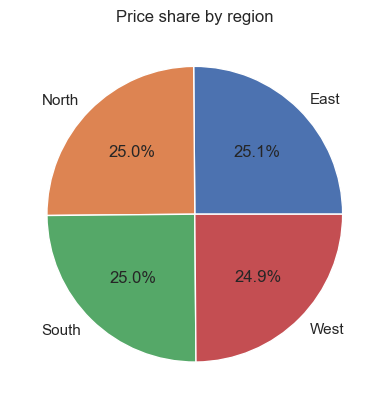

In [38]:
#pieplot
plt.pie(region_price["Price"],labels=region_price["Region"],autopct="%1.1f%%")
plt.title("Price share by region")
plt.show()

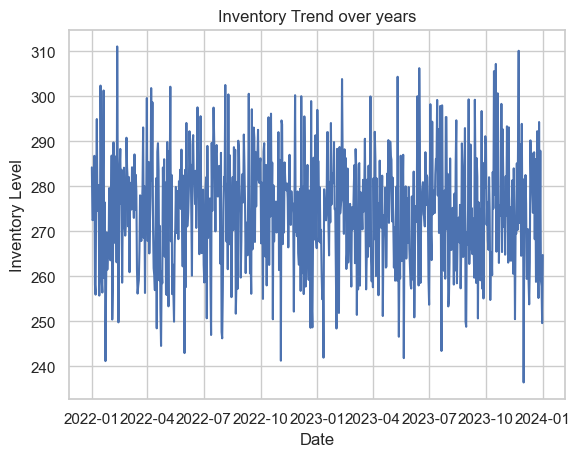

In [42]:
#lineplot according to trends years and date
line_trend=data.groupby("Date")["Inventory Level"].mean()
plt.plot(line_trend.index,line_trend.values)
plt.title("Inventory Trend over years")
plt.xlabel("Date")
plt.ylabel("Inventory Level")
plt.show()



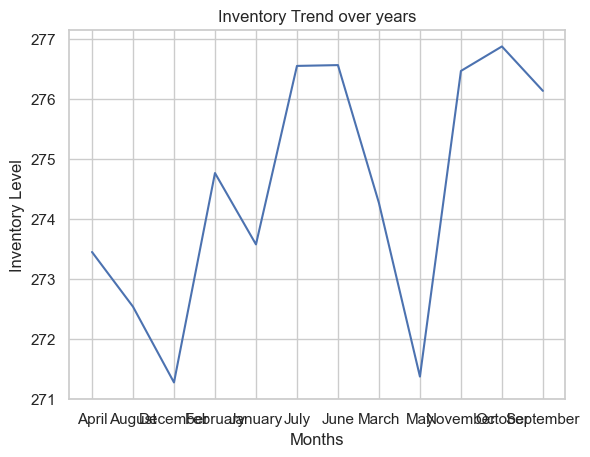

In [44]:
line_trend=data.groupby("Months")["Inventory Level"].mean()
plt.plot(line_trend.index,line_trend.values)
plt.title("Inventory Trend over years")
plt.xlabel("Months")
plt.ylabel("Inventory Level")
plt.show()


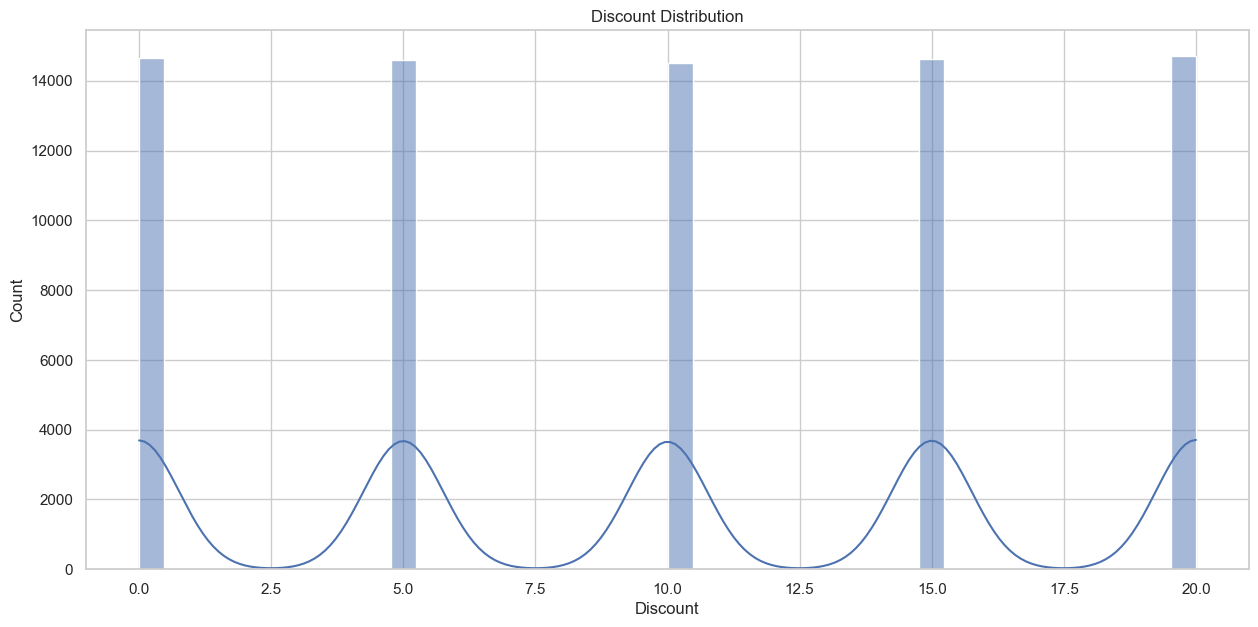

In [48]:
#histogram ( for price distribution)
plt.figure(figsize=(15,7))
sns.histplot(data["Discount"], kde=True)
plt.title("Discount Distribution")
plt.show()
           

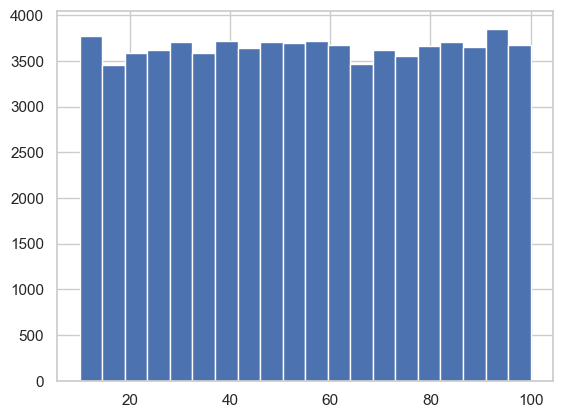

In [51]:
plt.hist(data["Price"],bins=20)
plt.show()